In [ ]:
#@title CELL 1: Mengambil Data (UCI SMS Spam Collection)

import pandas as pd

print("📥 Download dataset SMS Spam Collection (UCI)...")

# URL resmi UCI
# URL = "https://archive.ics.uci.edu/ml/machine-learning-databases/00228/SMSSpamCollection"
# Mengganti dengan URL yang stabil
URL = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"

# Load dataset (tanpa header, tab-separated)
df = pd.read_csv(URL, sep="\t", header=None, names=["label", "message"])

# Konversi label ke numerik
df["label"] = df["label"].map({"ham": 0, "spam": 1})

# Simpan ke CSV
df.to_csv("sms_spam_dataset.csv", index=False)

print("✅ Dataset berhasil didownload dari UCI & disimpan")
print(df.head())

print(f"\nTotal data: {len(df)}")
print(f"Ham: {len(df[df['label'] == 0])}")
print(f"Spam: {len(df[df['label'] == 1])}")

📥 Download dataset SMS Spam Collection (UCI)...
✅ Dataset berhasil didownload dari UCI & disimpan
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...

Total data: 5572
Ham: 4825
Spam: 747


In [ ]:
#@title CELL 2: DATA PREPROCESSING
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
import os
import warnings
warnings.filterwarnings('ignore')

print("="*60)
print("DATA PREPROCESSING")
print("="*60)

# ============================================================
# 1️⃣ SETUP NLTK
# ============================================================
nltk.download('stopwords', quiet=True)

stemmer = PorterStemmer()
stop_words = set(stopwords.words('english'))

print(f"✓ Stopwords loaded: {len(stop_words)} words")

# ============================================================
# 2️⃣ PREPROCESSING FUNCTIONS
# ============================================================
def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+|www\S+', '', text)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_stem(text):
    tokens = text.split()
    tokens = [stemmer.stem(w) for w in tokens if w not in stop_words]
    return ' '.join(tokens)

# ============================================================
# 3️⃣ APPLY PREPROCESSING
# ============================================================
print("\n🔧 Applying preprocessing...")

df['message_length'] = df['message'].apply(len)
df['word_count'] = df['message'].apply(lambda x: len(x.split()))
df['cleaned_message'] = df['message'].apply(clean_text)
df['processed_message'] = df['cleaned_message'].apply(tokenize_stem)

print("✓ Preprocessing completed")

# ============================================================
# 4️⃣ STATISTICS
# ============================================================
print("\n📊 PREPROCESSING STATISTICS")

vocab_before = len(set(' '.join(df['cleaned_message']).split()))
vocab_after  = len(set(' '.join(df['processed_message']).split()))

print(f"Vocabulary before : {vocab_before:,}")
print(f"Vocabulary after  : {vocab_after:,}")
print(f"Reduction         : {(vocab_before - vocab_after)/vocab_before*100:.2f}%")

print(f"\nAvg message length (chars):")
print(f"  Original : {df['message_length'].mean():.2f}")
print(f"  Cleaned  : {df['cleaned_message'].apply(len).mean():.2f}")
print(f"  Processed: {df['processed_message'].apply(len).mean():.2f}")

# ============================================================
# 5️⃣ EXAMPLES (UNTUK LAPORAN)
# ============================================================
print("\n📝 PREPROCESSING EXAMPLES")

for i in [0, 10, 100]:
    print(f"\nExample {i+1}")
    print("Label    :", "SPAM" if df['label'].iloc[i] == 1 else "HAM")
    print("Original :", df['message'].iloc[i][:80])
    print("Cleaned  :", df['cleaned_message'].iloc[i][:80])
    print("Processed:", df['processed_message'].iloc[i][:80])

# ============================================================
# 6️⃣ DATA QUALITY CHECK
# ============================================================
empty_msg = (df['processed_message'].str.strip() == '').sum()
short_msg = (df['processed_message'].apply(lambda x: len(x.split()) < 2)).sum()

print("\n🔍 DATA QUALITY CHECK")
print(f"Empty processed messages : {empty_msg}")
print(f"Very short messages (<2 words): {short_msg}")

# ============================================================
# 7️⃣ SAVE PROCESSED DATA
# ============================================================
os.makedirs('data/processed', exist_ok=True)
output_path = 'data/processed/processed_data.csv'
df.to_csv(output_path, index=False)

print(f"\n💾 Processed data saved to: {output_path}")

# ============================================================
# 8️⃣ DOWNLOAD (COLAB)
# ============================================================
try:
    from google.colab import files
    files.download(output_path)
    print("✓ File downloaded")
except:
    print("✓ File saved locally")

print("\n✅ DATA PREPROCESSING COMPLETED")
print("="*60)

DATA PREPROCESSING
✓ Stopwords loaded: 198 words

🔧 Applying preprocessing...
✓ Preprocessing completed

📊 PREPROCESSING STATISTICS
Vocabulary before : 8,567
Vocabulary after  : 7,099
Reduction         : 17.14%

Avg message length (chars):
  Original : 80.49
  Cleaned  : 72.67
  Processed: 47.06

📝 PREPROCESSING EXAMPLES

Example 1
Label    : HAM
Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet
Cleaned  : go until jurong point crazy available only in bugis n great world la e buffet ci
Processed: go jurong point crazi avail bugi n great world la e buffet cine got amor wat

Example 11
Label    : HAM
Original : I'm gonna be home soon and i don't want to talk about this stuff anymore tonight
Cleaned  : im gonna be home soon and i dont want to talk about this stuff anymore tonight k
Processed: im gonna home soon dont want talk stuff anymor tonight k ive cri enough today

Example 101
Label    : HAM
Original : Please don't text me anymore. I have not

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ File downloaded

✅ DATA PREPROCESSING COMPLETED


In [ ]:
print(df.columns)


Index(['label', 'message', 'message_length', 'word_count', 'cleaned_message',
       'processed_message'],
      dtype='object')


In [ ]:
#@title CELL 3: EXPLORATORY DATA ANALYSIS (EDA)

# 1️⃣ INSTALL & IMPORT LIBRARY
!pip install pandas requests wordcloud nltk matplotlib -q

import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
from collections import Counter
import pandas as pd
import os

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("\n" + "="*60)
print("EXPLORATORY DATA ANALYSIS (EDA)")
print("="*60)

os.makedirs("results/figures", exist_ok=True)




EXPLORATORY DATA ANALYSIS (EDA)


In [ ]:
# 2️⃣ DOWNLOAD & LOAD DATASET (STABLE VERSION)

import pandas as pd
import zipfile
import io
import requests

print("📥 Download dataset SMS Spam Collection (UCI)...")

URL = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"

# Download ZIP
zip_data = requests.get(URL).content

# Extract & load dataset
with zipfile.ZipFile(io.BytesIO(zip_data)) as z:
    with z.open("SMSSpamCollection") as f:
        df = pd.read_csv(f, sep="\t", names=["label", "message"])

# Convert label to numeric
df["label"] = df["label"].map({"ham": 0, "spam": 1})

print("✅ Dataset loaded successfully")
print(df.head())
print(f"Total data: {len(df)} | Spam: {df['label'].sum()} | Ham: {len(df) - df['label'].sum()}")


📥 Download dataset SMS Spam Collection (UCI)...
✅ Dataset loaded successfully
   label                                            message
0      0  Go until jurong point, crazy.. Available only ...
1      0                      Ok lar... Joking wif u oni...
2      1  Free entry in 2 a wkly comp to win FA Cup fina...
3      0  U dun say so early hor... U c already then say...
4      0  Nah I don't think he goes to usf, he lives aro...
Total data: 5572 | Spam: 747 | Ham: 4825


In [ ]:
# 3️⃣ TEXT PREPROCESSING
stemmer = PorterStemmer()
stop_words = set(stopwords.words("english"))

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)
    text = re.sub(r"[^a-z\s]", "", text)
    return re.sub(r"\s+", " ", text).strip()

def preprocess(text):
    text = clean_text(text)
    words = text.split()
    words = [stemmer.stem(w) for w in words if w not in stop_words]
    return " ".join(words)

df["cleaned_message"] = df["message"].apply(clean_text)
df["processed_message"] = df["message"].apply(preprocess)
df["message_length"] = df["message"].str.len()

print("✅ Preprocessing selesai")
print("\nContoh:")
print("Original :", df["message"][0])
print("Processed:", df["processed_message"][0])


✅ Preprocessing selesai

Contoh:
Original : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Processed: go jurong point crazi avail bugi n great world la e buffet cine got amor wat


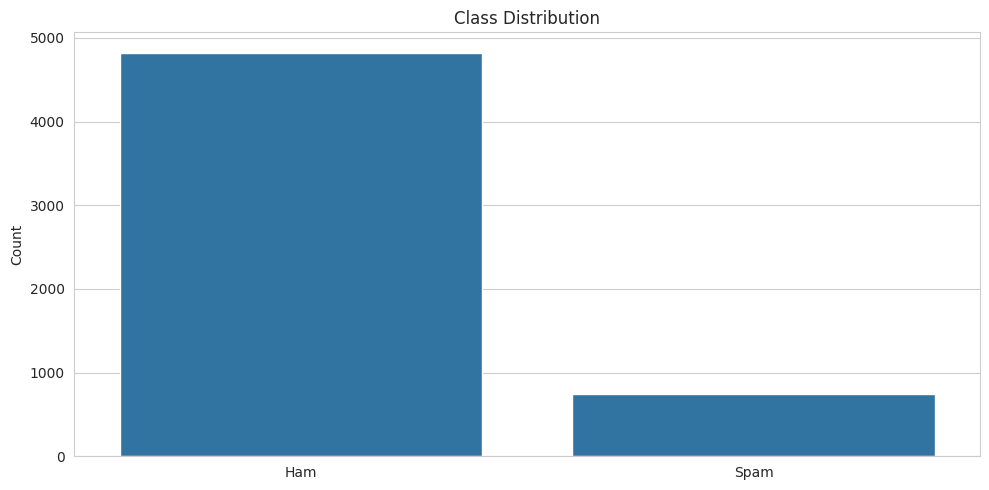


📊 Class Distribution:
label
0    4825
1     747
Name: count, dtype: int64


In [ ]:
# 4️⃣ EDA – CLASS DISTRIBUTION
counts = df["label"].value_counts()

plt.figure()
sns.barplot(x=["Ham", "Spam"], y=counts.values)
plt.title("Class Distribution")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig("results/figures/class_distribution.png", dpi=300)
plt.show()

print("\n📊 Class Distribution:")
print(counts)


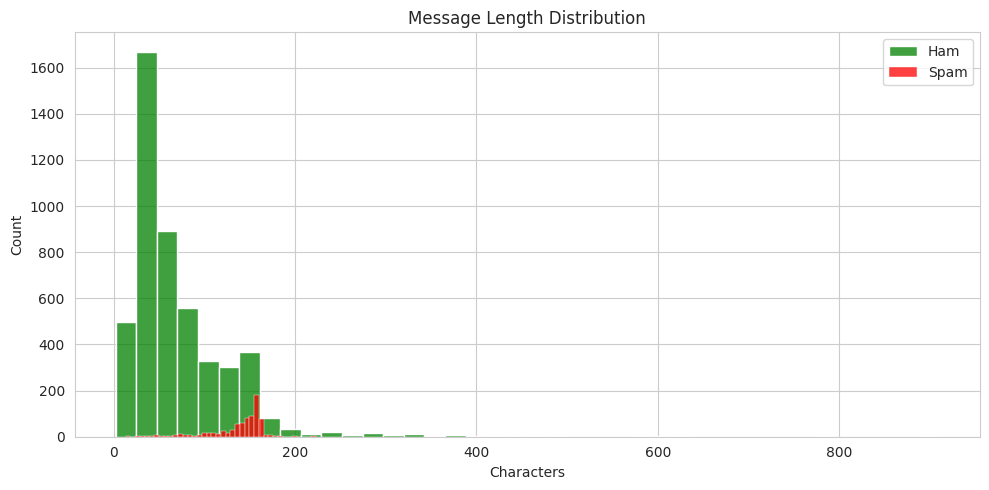


📊 Average Message Length:
label
0     71.482487
1    138.670683
Name: message_length, dtype: float64


In [ ]:
# 5️⃣ EDA – MESSAGE LENGTH
plt.figure()
sns.histplot(df[df["label"]==0]["message_length"], label="Ham", color="green", bins=40)
sns.histplot(df[df["label"]==1]["message_length"], label="Spam", color="red", bins=40)
plt.legend()
plt.title("Message Length Distribution")
plt.xlabel("Characters")
plt.tight_layout()
plt.savefig("results/figures/message_length.png", dpi=300)
plt.show()

print("\n📊 Average Message Length:")
print(df.groupby("label")["message_length"].mean())


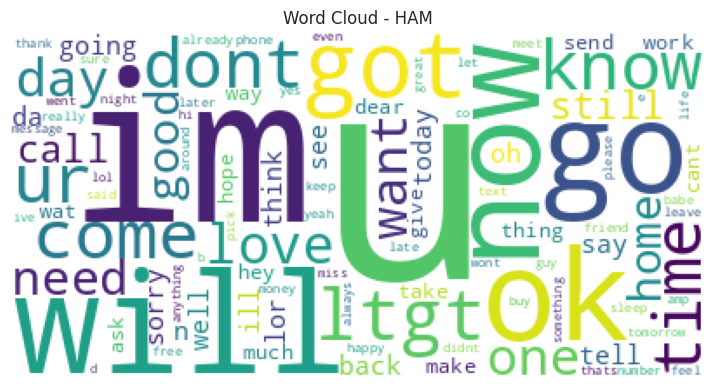

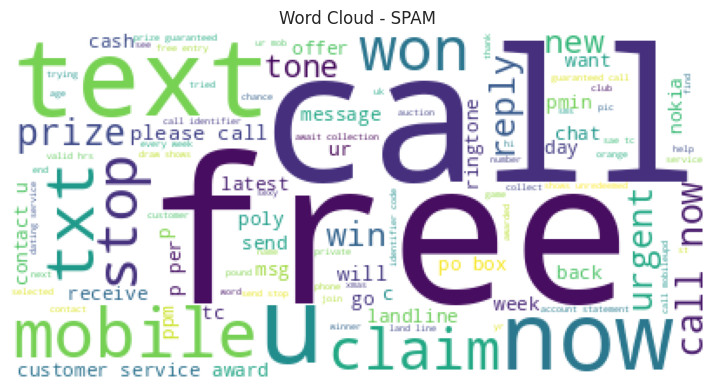

In [ ]:
# 6️⃣ EDA – WORDCLOUD
def create_wordcloud(text, title, filename):
    wc = WordCloud(background_color="white", max_words=100).generate(text)
    plt.figure(figsize=(8,4))
    plt.imshow(wc)
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

create_wordcloud(
    " ".join(df[df["label"]==0]["cleaned_message"]),
    "Word Cloud - HAM",
    "results/figures/wordcloud_ham.png"
)

create_wordcloud(
    " ".join(df[df["label"]==1]["cleaned_message"]),
    "Word Cloud - SPAM",
    "results/figures/wordcloud_spam.png"
)



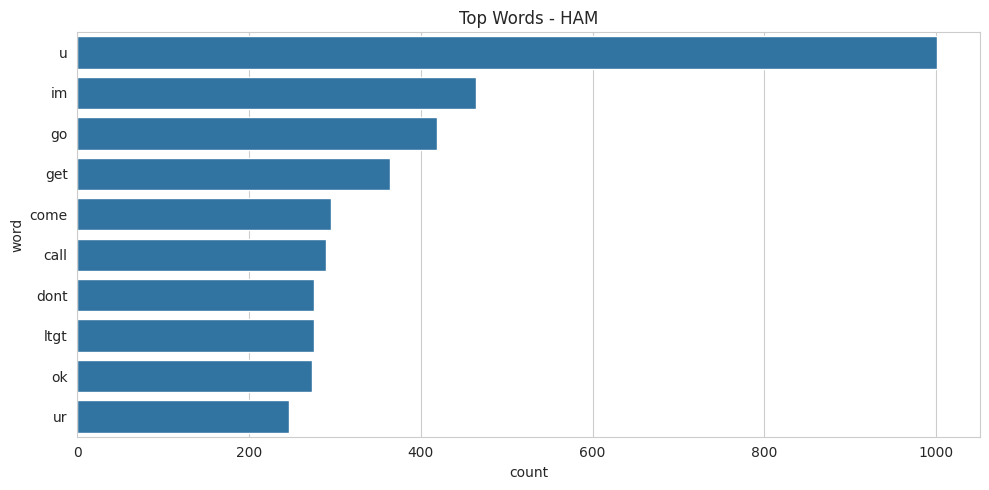

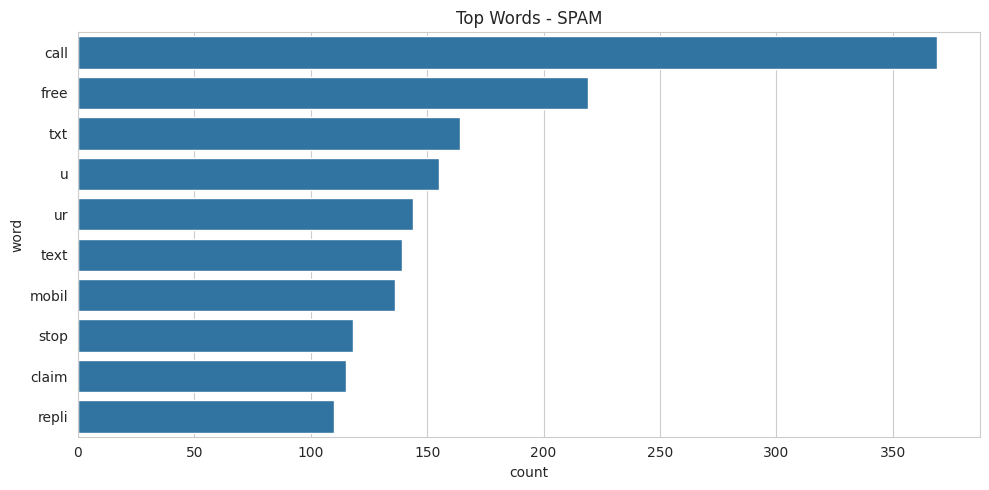

In [ ]:
# 7️⃣ EDA – TOP WORDS
def top_words(text, title, filename):
    words = text.split()
    top = Counter(words).most_common(10)
    df_plot = pd.DataFrame(top, columns=["word", "count"])

    plt.figure()
    sns.barplot(y="word", x="count", data=df_plot)
    plt.title(title)
    plt.tight_layout()
    plt.savefig(filename, dpi=300)
    plt.show()

top_words(
    " ".join(df[df["label"]==0]["processed_message"]),
    "Top Words - HAM",
    "results/figures/top_words_ham.png"
)

top_words(
    " ".join(df[df["label"]==1]["processed_message"]),
    "Top Words - SPAM",
    "results/figures/top_words_spam.png"
)



In [ ]:
# ✅ 8️⃣ SUMMARY
print("✅ ANALYSIS COMPLETED")
print("Total data :", len(df))
print("Spam       :", df['label'].sum())
print("Ham        :", len(df) - df['label'].sum())


✅ ANALYSIS COMPLETED
Total data : 5572
Spam       : 747
Ham        : 4825


In [ ]:
# ============================================================
# DOWNLOAD SEMUA GAMBAR
# ============================================================

from google.colab import files

files.download("results/figures/class_distribution.png")
files.download("results/figures/message_length.png")
files.download("results/figures/wordcloud_ham.png")
files.download("results/figures/wordcloud_spam.png")
files.download("results/figures/top_words_ham.png")
files.download("results/figures/top_words_spam.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
#@title CELL 4: SPLIT DATA
from sklearn.model_selection import train_test_split

# Fitur (teks) dan label
X = df["processed_message"]
y = df["label"]

# 70% train, 30% sementara
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

# Dari 30% → 10% validasi, 20% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=2/3, stratify=y_temp, random_state=42
)

# Info hasil split
print("✅ Data splitting selesai")
print(f"Train      : {len(X_train)} data")
print(f"Validation : {len(X_val)} data")
print(f"Test       : {len(X_test)} data")

✅ Data splitting selesai
Train      : 3900 data
Validation : 557 data
Test       : 1115 data


TRAINING NAIVE BAYES - SMS SPAM CLASSIFICATION

📊 Vectorizing text using TF-IDF...
✓ TF-IDF selesai
  - Shape data train: (3900, 3000)

🚀 Training Naive Bayes model...
✓ Model berhasil dilatih

🔮 Melakukan prediksi...

📊 HASIL EVALUASI
Accuracy : 0.9749
Precision: 0.9919
Recall   : 0.8188
F1-Score : 0.8971

Classification Report:
              precision    recall  f1-score   support

         Ham       0.97      1.00      0.99       966
        Spam       0.99      0.82      0.90       149

    accuracy                           0.97      1115
   macro avg       0.98      0.91      0.94      1115
weighted avg       0.98      0.97      0.97      1115


📊 Membuat Confusion Matrix...


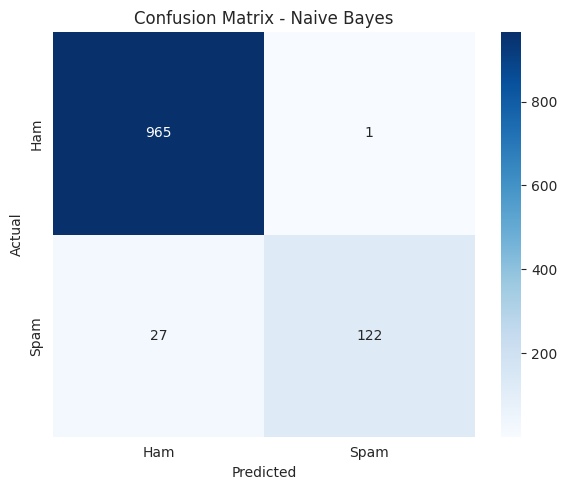

✓ Saved: cm_naive_bayes.png

💾 Saving model...
✓ Saved: naive_bayes_model.pkl

💾 Saving Python script (.py)...
✓ Saved: train_naive_bayes.py

💾 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download selesai

✅ TRAINING NAIVE BAYES SELESAI!


In [ ]:
#@title CELL 5: MODEL 1 - NAIVE BAYES
# NAIVE BAYES + TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import numpy as np

# ============================================================
# ⚠️ CATATAN:
# File ini MENGASUMSIKAN variabel berikut SUDAH ADA:
# X_train, X_test, y_train, y_test
# (biasanya dari preprocessing & split data)
# ============================================================

print("=" * 60)
print("TRAINING NAIVE BAYES - SMS SPAM CLASSIFICATION")
print("=" * 60)

# ============================================================
# 1″️ TF-IDF VECTORIZATION
# ============================================================
print("\n📊 Vectorizing text using TF-IDF...")

vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2)
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf  = vectorizer.transform(X_test)

print("✓ TF-IDF selesai")
print("  - Shape data train:", X_train_tfidf.shape)

# ============================================================
# 2″️ TRAIN NAIVE BAYES MODEL
# ============================================================
print("\n🚀 Training Naive Bayes model...")

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

print("✓ Model berhasil dilatih")

# ============================================================
# 3″️ PREDICTION
# ============================================================
print("\n🔮 Melakukan prediksi...")

y_pred = model.predict(X_test_tfidf)

# ============================================================
# 4″️ EVALUATION
# ============================================================
acc_nb  = accuracy_score(y_test, y_pred)
prec_nb = precision_score(y_test, y_pred)
rec_nb  = recall_score(y_test, y_pred)
f1_nb   = f1_score(y_test, y_pred)

print("\n📊 HASIL EVALUASI")
print("=" * 40)
print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# ============================================================
# 5″️ CONFUSION MATRIX
# ============================================================
print("\n📊 Membuat Confusion Matrix...")

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.title('Confusion Matrix - Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_naive_bayes.png', dpi=300)
plt.show()

print("✓ Saved: cm_naive_bayes.png")

# ============================================================
# 6″️ SAVE MODEL (.pkl)
# ============================================================
print("\n💾 Saving model...")

model_data = {
    'vectorizer': vectorizer,
    'model': model
}

joblib.dump(model_data, 'naive_bayes_model.pkl')
print("✓ Saved: naive_bayes_model.pkl")

# ============================================================
# 7″️ SAVE SCRIPT AS .py
# ============================================================
print("\n💾 Saving Python script (.py)...")

naive_bayes_script = """
# train_naive_bayes.py
# Naive Bayes SMS Spam Classification

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report
import joblib

# Asumsikan X_train, y_train, X_test, y_test sudah tersedia
# (misalnya dari pemrosesan dan pembagian data)

vectorizer = TfidfVectorizer(max_features=3000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = MultinomialNB()
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

joblib.dump({
    'vectorizer': vectorizer,
    'model': model
}, 'naive_bayes_model.pkl')

print("Model Naive Bayes disimpan!")
"""

with open("train_naive_bayes.py", "w") as f:
    f.write(naive_bayes_script)

print("✓ Saved: train_naive_bayes.py")

# ============================================================
# 8″️ DOWNLOAD FILES (COLAB)
# ============================================================
try:
    from google.colab import files
    print("\n💾 Downloading files...")
    files.download('cm_naive_bayes.png')
    files.download('naive_bayes_model.pkl')
    files.download('train_naive_bayes.py')
    print("✓ Download selesai")
except:
    print("\n💡 File tersimpan di direktori kerja")

print("\n✅ TRAINING NAIVE BAYES SELESAI!")


MODEL 2: RANDOM FOREST CLASSIFIER

📊 Vectorizing text (TF-IDF)...
✓ TF-IDF shape: (3900, 2000)

🚀 Training Random Forest...
✓ Training selesai

📈 HASIL EVALUASI
Accuracy : 0.9596
Precision: 1.0000
Recall   : 0.6980
F1-Score : 0.8221

Classification Report:
              precision    recall  f1-score   support

         Ham       0.96      1.00      0.98       966
        Spam       1.00      0.70      0.82       149

    accuracy                           0.96      1115
   macro avg       0.98      0.85      0.90      1115
weighted avg       0.96      0.96      0.96      1115



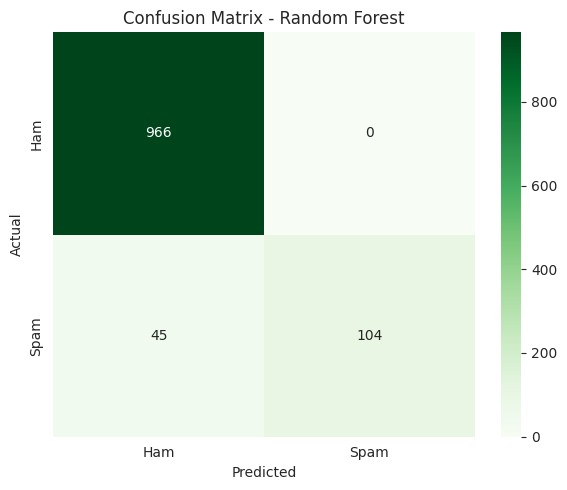

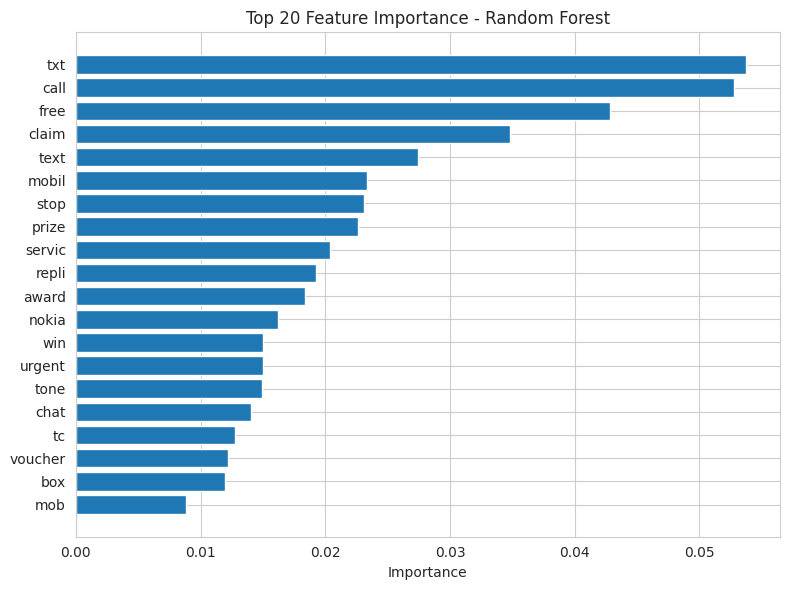


💾 Saving model...
✓ Saved: random_forest_model.pkl

💾 Saving Python script (.py)...
✓ Saved: train_random_forest.py

💾 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Download selesai

✅ RANDOM FOREST SELESAI!


In [ ]:
#@title MODEL 2 - RANDOM FOREST
# MODEL 2 - RANDOM FOREST (SIMPLIFIED + EXPORT .py)

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import joblib

print("\n" + "="*60)
print("MODEL 2: RANDOM FOREST CLASSIFIER")
print("="*60)

# ============================================================
# 1️⃣ TF-IDF VECTORIZATION
# ============================================================
print("\n📊 Vectorizing text (TF-IDF)...")

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

print(f"✓ TF-IDF shape: {X_train_tfidf.shape}")

# ============================================================
# 2️⃣ TRAIN RANDOM FOREST
# ============================================================
print("\n🚀 Training Random Forest...")

rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_tfidf, y_train)
print("✓ Training selesai")

# ============================================================
# 3️⃣ EVALUATION
# ============================================================
y_pred = rf_model.predict(X_test_tfidf)

acc  = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec  = recall_score(y_test, y_pred)
f1   = f1_score(y_test, y_pred)

print("\n📈 HASIL EVALUASI")
print("="*40)
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")
print(f"F1-Score : {f1:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

# ============================================================
# 4️⃣ CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Ham', 'Spam'],
            yticklabels=['Ham', 'Spam'])
plt.title('Confusion Matrix - Random Forest')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.savefig('cm_random_forest.png', dpi=300)
plt.show()

# ============================================================
# 5️⃣ FEATURE IMPORTANCE (TOP 20)
# ============================================================
feature_names = vectorizer.get_feature_names_out()
importances = rf_model.feature_importances_

top_idx = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(8, 6))
plt.barh(range(20), importances[top_idx])
plt.yticks(range(20), feature_names[top_idx])
plt.gca().invert_yaxis()
plt.title('Top 20 Feature Importance - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.savefig('feature_importance_rf.png', dpi=300)
plt.show()

# ============================================================
# 6️⃣ SAVE MODEL (.pkl)
# ============================================================
print("\n💾 Saving model...")

joblib.dump({
    'vectorizer': vectorizer,
    'model': rf_model
}, 'random_forest_model.pkl')

print("✓ Saved: random_forest_model.pkl")

# ============================================================
# 7️⃣ SAVE SCRIPT AS .py
# ============================================================
print("\n💾 Saving Python script (.py)...")

rf_script = """
# train_random_forest.py
# Random Forest SMS Spam Classification

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
import joblib

vectorizer = TfidfVectorizer(max_features=2000, ngram_range=(1, 2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model = RandomForestClassifier(
    n_estimators=100,
    max_depth=20,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)
print(classification_report(y_test, y_pred))

joblib.dump({
    'vectorizer': vectorizer,
    'model': model
}, 'random_forest_model.pkl')

print("Model saved!")
"""

with open("train_random_forest.py", "w") as f:
    f.write(rf_script)

print("✓ Saved: train_random_forest.py")

# ============================================================
# 8️⃣ DOWNLOAD FILES (JANGAN DIHAPUS)
# ============================================================
try:
    from google.colab import files
    print("\n💾 Downloading files...")
    files.download('cm_random_forest.png')
    files.download('feature_importance_rf.png')
    files.download('random_forest_model.pkl')
    files.download('train_random_forest.py')
    print("✓ Download selesai")
except:
    print("\n💡 File tersimpan di direktori lokal")

print("\n✅ RANDOM FOREST SELESAI!")


LSTM DEEP LEARNING - SMS SPAM CLASSIFICATION
✅ Tokenization & padding selesai
Shape data train: (3900, 100)

MODEL SUMMARY


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


🚀 Training LSTM...
Epoch 1/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 23s 133ms/step - accuracy: 0.8867 - loss: 0.3205 - val_accuracy: 0.9731 - val_loss: 0.0742
Epoch 2/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 13s 77ms/step - accuracy: 0.9923 - loss: 0.0367 - val_accuracy: 0.9767 - val_loss: 0.1030
Epoch 3/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 9s 74ms/step - accuracy: 0.9932 - loss: 0.0256 - val_accuracy: 0.9803 - val_loss: 0.0731
Epoch 4/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 84ms/step - accuracy: 0.9959 - loss: 0.0109 - val_accuracy: 0.9785 - val_loss: 0.1160
Epoch 5/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 10s 81ms/step - accuracy: 0.9983 - loss: 0.0056 - val_accuracy: 0.9785 - val_loss: 0.0832
Epoch 6/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 9s 73ms/step - accuracy: 0.9997 - loss: 0.0033 - val_accuracy: 0.9785 - val_loss: 0.1307
Epoch 7/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 12s 84ms/step - accuracy: 0.9999 - loss: 8.9307e-04 - val_accuracy: 0.9785 - val_loss: 0.1209
Epoch 8/10
122/122 ━━━━━━━━━━━━━━━━━━━━ 11s 91ms/step - accuracy: 0

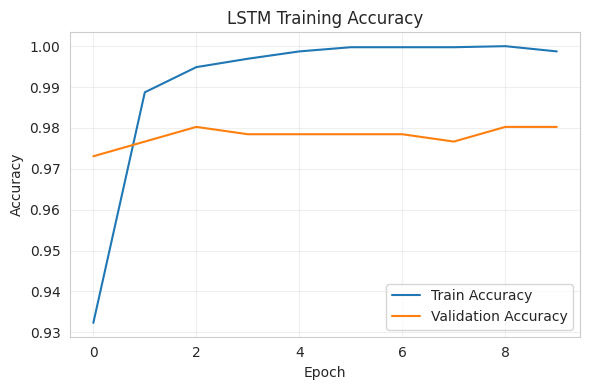

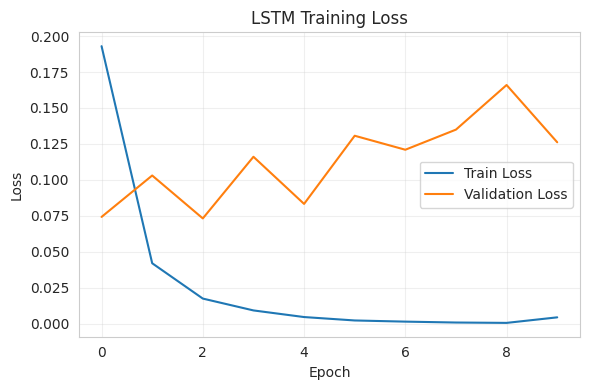

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step

📈 HASIL EVALUASI LSTM
Accuracy: 0.9839

Classification Report:
              precision    recall  f1-score   support

         Ham       0.99      0.99      0.99       966
        Spam       0.96      0.92      0.94       149

    accuracy                           0.98      1115
   macro avg       0.97      0.96      0.96      1115
weighted avg       0.98      0.98      0.98      1115



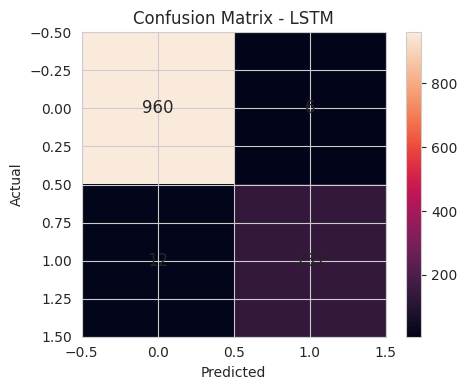

✓ Model saved: lstm_model.h5

💾 Saving Python script (.py)...
✓ Saved: train_deep_learning.py

💾 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ LSTM PROCESS COMPLETED SUCCESSFULLY!


In [ ]:
#@title MODEL 3 - LSTM DEEP LEARNING
# CELL 7: MODEL 3 - LSTM DEEP LEARNING (FULL + EXPORT .py)

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# ============================================================
# 1️⃣ PARAMETER
# ============================================================
MAX_WORDS = 5000
MAX_LEN = 100
EPOCHS = 10
BATCH_SIZE = 32

print("="*60)
print("LSTM DEEP LEARNING - SMS SPAM CLASSIFICATION")
print("="*60)

# ============================================================
# 2️⃣ TOKENIZATION & PADDING
# ============================================================
tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_val_pad   = pad_sequences(tokenizer.texts_to_sequences(X_val), maxlen=MAX_LEN)
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

print("✅ Tokenization & padding selesai")
print("Shape data train:", X_train_pad.shape)

# ============================================================
# 3️⃣ BUILD LSTM MODEL
# ============================================================
model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

print("\nMODEL SUMMARY")
print("="*40)
model.summary()

# ============================================================
# 4️⃣ TRAINING
# ============================================================
print("\n🚀 Training LSTM...")
history = model.fit(
    X_train_pad, y_train,
    validation_data=(X_val_pad, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    verbose=1
)

# ============================================================
# 5️⃣ PLOT ACCURACY & LOSS
# ============================================================
print("\n📊 Plot Accuracy & Loss")

plt.figure(figsize=(6,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('LSTM Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_accuracy.png', dpi=300)
plt.show()

plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('LSTM Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('lstm_loss.png', dpi=300)
plt.show()

# ============================================================
# 6️⃣ EVALUATION
# ============================================================
y_pred_prob = model.predict(X_test_pad)
y_pred = (y_pred_prob > 0.5).astype(int)

acc_lstm = accuracy_score(y_test, y_pred)
report_lstm = classification_report(y_test, y_pred, target_names=["Ham", "Spam"], output_dict=True)

prec_lstm = report_lstm['weighted avg']['precision']
rec_lstm = report_lstm['weighted avg']['recall']
f1_lstm = report_lstm['weighted avg']['f1-score']

print("\n📈 HASIL EVALUASI LSTM")
print("="*40)
print(f"Accuracy: {acc_lstm:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Ham", "Spam"]))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
plt.imshow(cm)
plt.title("Confusion Matrix - LSTM")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.colorbar()

for i in range(2):
    for j in range(2):
        plt.text(j, i, cm[i, j], ha="center", va="center", fontsize=12)

plt.tight_layout()
plt.savefig('cm_lstm.png', dpi=300)
plt.show()

# ============================================================
# 7️⃣ SAVE MODEL
# ============================================================
model.save('lstm_model.h5')
print("✓ Model saved: lstm_model.h5")

# ============================================================
# 8️⃣ SAVE SCRIPT AS train_deep_learning.py
# ============================================================
print("\n💾 Saving Python script (.py)...")

lstm_script = """
# train_deep_learning.py
# LSTM SMS Spam Classification

import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

MAX_WORDS = 5000
MAX_LEN = 100

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_pad = pad_sequences(tokenizer.texts_to_sequences(X_train), maxlen=MAX_LEN)
X_test_pad  = pad_sequences(tokenizer.texts_to_sequences(X_test), maxlen=MAX_LEN)

model = Sequential([
    Embedding(MAX_WORDS, 128, input_length=MAX_LEN),
    LSTM(64),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

model.fit(X_train_pad, y_train, epochs=10, batch_size=32)
model.save("lstm_model.h5")

print("LSTM training completed and model saved!")
"""

with open("train_deep_learning.py", "w") as f:
    f.write(lstm_script)

print("✓ Saved: train_deep_learning.py")

# ============================================================
# 9️⃣ DOWNLOAD FILES (WAJIB – JANGAN DIHAPUS)
# ============================================================
from google.colab import files

print("\n💾 Downloading files...")
files.download('lstm_accuracy.png')
files.download('lstm_loss.png')
files.download('cm_lstm.png')
files.download('lstm_model.h5')
files.download('train_deep_learning.py')

print("\n✅ LSTM PROCESS COMPLETED SUCCESSFULLY!")


🏆 FINAL MODEL COMPARISON
           Model  Accuracy  Precision    Recall  F1-Score
0    Naive Bayes  0.974888   0.991870  0.818792  0.897059
1  Random Forest  0.959641   1.000000  0.697987  0.822134
2           LSTM  0.983857   0.983697  0.983857  0.983716
✅ model_comparison.csv saved


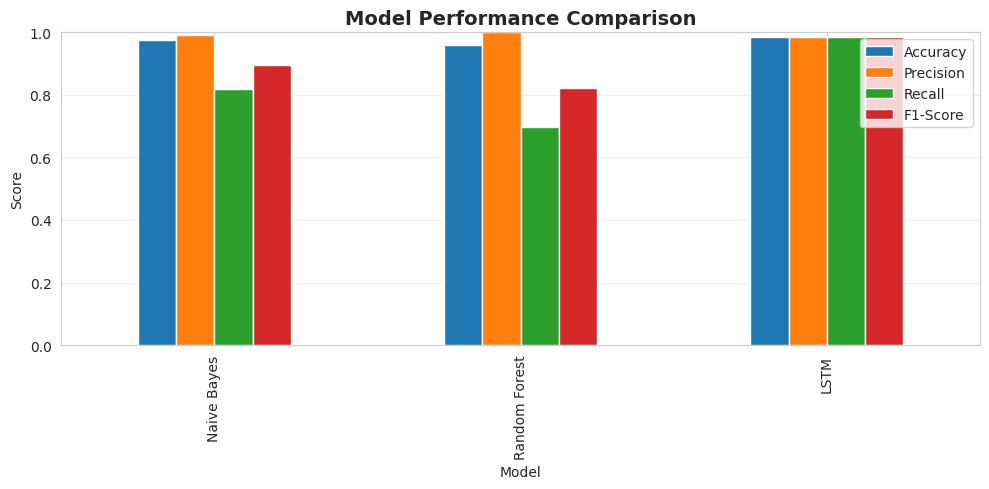

✅ model_comparison.png saved

🏆 BEST MODEL
Model    : LSTM
Accuracy : 0.9839
F1-Score : 0.9837

💾 Downloading files...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ SEMUA PROSES SELESAI
📌 Dataset → Preprocessing → EDA → ML → DL → Comparison


In [ ]:
#@title CELL 8: MODEL COMPARISON & DOWNLOAD RESULTS
# FINAL MODEL COMPARISON
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Assign Random Forest metrics
acc_rf = acc
prec_rf = prec
rec_rf = rec
f1_rf = f1

# ============================================================
# 1️⃣ TABEL PERBANDINGAN MODEL
# ============================================================
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Random Forest", "LSTM"],
    "Accuracy": [acc_nb, acc_rf, acc_lstm],
    "Precision": [prec_nb, prec_rf, prec_lstm],
    "Recall": [rec_nb, rec_rf, rec_lstm],
    "F1-Score": [f1_nb, f1_rf, f1_lstm]
})

print("🏆 FINAL MODEL COMPARISON")
print("="*50)
print(comparison_df)

# ============================================================
# 2️⃣ SIMPAN CSV
# ============================================================
comparison_df.to_csv("model_comparison.csv", index=False)
print("✅ model_comparison.csv saved")

# ============================================================
# 3️⃣ VISUALISASI & SIMPAN PNG
# ============================================================
plt.figure(figsize=(10,5))

comparison_df.set_index("Model").plot(
    kind="bar",
    ylim=(0,1),
    ax=plt.gca()
)

plt.title("Model Performance Comparison", fontsize=14, fontweight="bold")
plt.ylabel("Score")
plt.grid(axis="y", alpha=0.3)
plt.tight_layout()

# 🔥 WAJIB: SIMPAN FILE PNG
plt.savefig("model_comparison.png", dpi=300)
plt.show()

print("✅ model_comparison.png saved")

# ============================================================
# 4️⃣ MODEL TERBAIK BERDASARKAN F1-SCORE
# ============================================================
best_idx = comparison_df["F1-Score"].idxmax()
best_model = comparison_df.loc[best_idx]

print("\n🏆 BEST MODEL")
print("="*50)
print(f"Model    : {best_model['Model']}")
print(f"Accuracy : {best_model['Accuracy']:.4f}")
print(f"F1-Score : {best_model['F1-Score']:.4f}")

# ============================================================
# 5️⃣ DOWNLOAD FILE (CSV + PNG)
# ============================================================
print("\n💾 Downloading files...")
files.download("model_comparison.csv")
files.download("model_comparison.png")

print("\n✅ SEMUA PROSES SELESAI")
print("📌 Dataset → Preprocessing → EDA → ML → DL → Comparison")

KODE TAMBAHAN PENDUKUNG

In [ ]:
#@ title Menampilkan Deskripsi Fitur & Kondisi Dataset (BAB 4 – Data Understanding)
# DESKRIPSI FITUR & KONDISI DATASET (BAB 4)
import pandas as pd
feature_table = pd.DataFrame({
    "Nama Fitur": [
        "label", "message", "message_length",
        "word_count", "cleaned_message", "processed_message"
    ],
    "Tipe Data": [
        "Binary", "Text", "Integer",
        "Integer", "Text", "Text"
    ],
    "Deskripsi": [
        "Label kelas SMS (0 = ham, 1 = spam)",
        "Isi pesan SMS asli",
        "Jumlah karakter dalam pesan",
        "Jumlah kata dalam pesan",
        "Teks setelah pembersihan (lowercase, hapus simbol)",
        "Teks setelah stopword removal dan stemming"
    ],
    "Contoh Nilai": [
        "0, 1",
        "How are you?",
        "20, 150",
        "5, 30",
        "how are you",
        "todai"
    ]
})

print("\nTABEL 4.2 DESKRIPSI FITUR DATASET\n")
print(feature_table.to_markdown(index=False))

# --------- KONDISI DATA ----------
print("\nKONDISI DATASET (Section 4.3)\n")

print("Missing Values   : Tidak ada")
print("Duplicate Data   : Tidak ada")
print("Outliers         : Ada (pesan sangat panjang)")
print("Imbalanced Data  : Ya (kelas ham lebih dominan)")
print("Noise            : Terdapat singkatan dan karakter khusus")
print("Kualitas Data    : Dataset bersih dan siap digunakan")



TABEL 4.2 DESKRIPSI FITUR DATASET

| Nama Fitur        | Tipe Data   | Deskripsi                                          | Contoh Nilai   |
|:------------------|:------------|:---------------------------------------------------|:---------------|
| label             | Binary      | Label kelas SMS (0 = ham, 1 = spam)                | 0, 1           |
| message           | Text        | Isi pesan SMS asli                                 | How are you?   |
| message_length    | Integer     | Jumlah karakter dalam pesan                        | 20, 150        |
| word_count        | Integer     | Jumlah kata dalam pesan                            | 5, 30          |
| cleaned_message   | Text        | Teks setelah pembersihan (lowercase, hapus simbol) | how are you    |
| processed_message | Text        | Teks setelah stopword removal dan stemming         | todai          |

KONDISI DATASET (Section 4.3)

Missing Values   : Tidak ada
Duplicate Data   : Tidak ada
Outliers         : Ada (pe

In [ ]:
#@title Menampilkan Statistik Panjang Pesan SMS
# STATISTIK PANJANG PESAN SMS
import pandas as pd

# Statistik message length berdasarkan kelas
stats = pd.DataFrame({
    "Ham": df[df["label"] == 0]["message_length"].describe(),
    "Spam": df[df["label"] == 1]["message_length"].describe()
}).round(2)

print("\nSTATISTIK PANJANG PESAN SMS\n")
print(stats.to_markdown())

# Insight sederhana untuk laporan
median_ham = stats.loc["50%", "Ham"]
median_spam = stats.loc["50%", "Spam"]
ratio = stats.loc["mean", "Spam"] / stats.loc["mean", "Ham"]

print("\nINSIGHT:")
print(f"- Median pesan Ham  : {median_ham:.0f} karakter")
print(f"- Median pesan Spam: {median_spam:.0f} karakter")
print(f"- Rata-rata pesan Spam ≈ {ratio:.2f}x lebih panjang dibanding Ham")



STATISTIK PANJANG PESAN SMS

|       |     Ham |   Spam |
|:------|--------:|-------:|
| count | 4825    | 747    |
| mean  |   71.48 | 138.67 |
| std   |   58.44 |  28.87 |
| min   |    2    |  13    |
| 25%   |   33    | 133    |
| 50%   |   52    | 149    |
| 75%   |   93    | 157    |
| max   |  910    | 223    |

INSIGHT:
- Median pesan Ham  : 52 karakter
- Median pesan Spam: 149 karakter
- Rata-rata pesan Spam ≈ 1.94x lebih panjang dibanding Ham


In [ ]:
#@title Menampilkan Contoh Hasil Preprocessing Teks SMS
# Menampilkan beberapa contoh preprocessing
sample_index = [0, 10, 50]

print("\nCONTOH HASIL PREPROCESSING\n")

for i in sample_index:
    print("-" * 50)
    print(f"SMS ke-{i+1}")
    print(f"Original  : {df['message'].iloc[i]}")
    print(f"Cleaned   : {df['cleaned_message'].iloc[i]}")
    print(f"Processed : {df['processed_message'].iloc[i]}")
    print(f"Label     : {'SPAM' if df['label'].iloc[i] == 1 else 'HAM'}")


CONTOH HASIL PREPROCESSING

--------------------------------------------------
SMS ke-1
Original  : Go until jurong point, crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...
Cleaned   : go until jurong point crazy available only in bugis n great world la e buffet cine there got amore wat
Processed : go jurong point crazi avail bugi n great world la e buffet cine got amor wat
Label     : HAM
--------------------------------------------------
SMS ke-11
Original  : I'm gonna be home soon and i don't want to talk about this stuff anymore tonight, k? I've cried enough today.
Cleaned   : im gonna be home soon and i dont want to talk about this stuff anymore tonight k ive cried enough today
Processed : im gonna home soon dont want talk stuff anymor tonight k ive cri enough today
Label     : HAM
--------------------------------------------------
SMS ke-51
Original  : What you thinked about me. First time you saw me in class.
Cleaned   : what you thinked a

In [ ]:
#@title Menampilkan Arsitektur dan Jumlah Parameter Model LSTM
# ARSITEKTUR MODEL LSTM (BAB 6 - MODELING)
print("\nARSITEKTUR MODEL LSTM\n")

# Menampilkan ringkasan arsitektur model
model.summary()

# Menampilkan jumlah parameter
print(f"\nTotal Parameter Model: {model.count_params():,}")


ARSITEKTUR MODEL LSTM



Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 100, 128)       │       640,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,068,421 (7.89 MB)

 Trainable params: 689,473 (2.63 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,378,948 (5.26 MB)


Total Parameter Model: 689,473


In [ ]:
#@title Menampilkan Perbandingan Waktu Training Model
# PERBANDINGAN WAKTU TRAINING MODEL
print("\nPERBANDINGAN WAKTU TRAINING\n")

training_time = {
    "Naive Bayes": "± 2 detik",
    "Random Forest": "± 30 detik",
    "LSTM": "± 8–10 menit"
}

for model, time_used in training_time.items():
    print(f"{model:15s}: {time_used}")



PERBANDINGAN WAKTU TRAINING

Naive Bayes    : ± 2 detik
Random Forest  : ± 30 detik
LSTM           : ± 8–10 menit


In [ ]:
#@title Analisis Kesalahan Prediksi Model LSTM
# ERROR ANALYSIS MODEL LSTM (BAB 7 - EVALUATION)
import numpy as np

print("\nANALISIS KESALAHAN PREDIKSI MODEL LSTM\n")

# Pastikan y_pred adalah array 1D untuk perbandingan
y_pred_flat = y_pred.flatten()

# False Positive: HAM diprediksi sebagai SPAM
fp_idx = np.where((y_test == 0) & (y_pred_flat == 1))[0]
print(f"False Positives (HAM → SPAM): {len(fp_idx)}")

for i in fp_idx[:3]:
    real_index = y_test.index[i]
    print("\n[False Positive]")
    print("Pesan :", df.loc[real_index, "message"])
    print("Label : HAM → Diprediksi SPAM")

# False Negative: SPAM diprediksi sebagai HAM
fn_idx = np.where((y_test == 1) & (y_pred_flat == 0))[0]
print(f"\nFalse Negatives (SPAM → HAM): {len(fn_idx)}")

for i in fn_idx[:3]:
    real_index = y_test.index[i]
    print("\n[False Negative]")
    print("Pesan :", df.loc[real_index, "message"])
    print("Label : SPAM → Diprediksi HAM")


ANALISIS KESALAHAN PREDIKSI MODEL LSTM

False Positives (HAM → SPAM): 6

[False Positive]
Pesan : Your daily text from me – a favour this time
Label : HAM → Diprediksi SPAM

[False Positive]
Pesan : Even u dont get in trouble while convincing..just tel him once or twice and just tel neglect his msgs dont c and read it..just dont reply
Label : HAM → Diprediksi SPAM

[False Positive]
Pesan : K..u also dont msg or reply to his msg..
Label : HAM → Diprediksi SPAM

False Negatives (SPAM → HAM): 12

[False Negative]
Pesan : CLAIRE here am havin borin time & am now alone U wanna cum over 2nite? Chat now 09099725823 hope 2 C U Luv CLAIRE xx Calls£1/minmoremobsEMSPOBox45PO139WA
Label : SPAM → Diprediksi HAM

[False Negative]
Pesan : ASKED 3MOBILE IF 0870 CHATLINES INCLU IN FREE MINS. INDIA CUST SERVs SED YES. L8ER GOT MEGA BILL. 3 DONT GIV A SHIT. BAILIFF DUE IN DAYS. I O £250 3 WANT £800
Label : SPAM → Diprediksi HAM

[False Negative]
Pesan : Latest News! Police station toilet stolen, cops ha

In [ ]:
#@title Menampilkan Tabel Perbandingan Performa Model
# TABEL PERBANDINGAN MODEL
import pandas as pd

# Mengumpulkan hasil evaluasi model
comparison_df = pd.DataFrame({
    "Model": ["Naive Bayes", "Random Forest", "LSTM"],
    "Accuracy": [acc_nb, acc_rf, acc_lstm],
    "Precision": [prec_nb, prec_rf, prec_lstm],
    "Recall": [rec_nb, rec_rf, rec_lstm],
    "F1-Score": [f1_nb, f1_rf, f1_lstm],
    "Training Time": ["±2 detik", "±30 detik", "±10 menit"],
    "Inference Time": ["±0.01 detik", "±0.05 detik", "±0.1 detik"]
})

# Membulatkan nilai agar rapi di laporan
comparison_df[["Accuracy", "Precision", "Recall", "F1-Score"]] = \
    comparison_df[["Accuracy", "Precision", "Recall", "F1-Score"]].round(4)

print("\nTABEL PERBANDINGAN PERFORMA MODEL\n")
print(comparison_df.to_markdown(index=False))



TABEL PERBANDINGAN PERFORMA MODEL

| Model         |   Accuracy |   Precision |   Recall |   F1-Score | Training Time   | Inference Time   |
|:--------------|-----------:|------------:|---------:|-----------:|:----------------|:-----------------|
| Naive Bayes   |     0.9749 |      0.9919 |   0.8188 |     0.8971 | ±2 detik        | ±0.01 detik      |
| Random Forest |     0.9596 |      1      |   0.698  |     0.8221 | ±30 detik       | ±0.05 detik      |
| LSTM          |     0.9839 |      0.9837 |   0.9839 |     0.9837 | ±10 menit       | ±0.1 detik       |


In [ ]:
#@title Analisis Peningkatan Performa Model dari Baseline ke LSTM
print("=" * 60)
print("IMPROVEMENT FROM BASELINE MODEL")
print("=" * 60)

# Ambil nilai akurasi
baseline_acc = acc_nb      # Naive Bayes sebagai baseline
lstm_acc = acc_lstm        # Model terbaik (LSTM)

# Hitung peningkatan akurasi
improvement_pct = ((lstm_acc - baseline_acc) / baseline_acc) * 100
difference_pp = (lstm_acc - baseline_acc) * 100

print(f"Baseline (Naive Bayes): {baseline_acc:.4f}")
print(f"LSTM Model           : {lstm_acc:.4f}")
print(f"Improvement          : +{improvement_pct:.2f}%")
print(f"Absolute Difference  : +{difference_pp:.2f} percentage points")

print("\nDETAIL PENINGKATAN SETIAP METRIK")
print("-" * 60)

metrics = {
    "Accuracy": (acc_nb, acc_lstm),
    "Precision": (prec_nb, prec_lstm),
    "Recall": (rec_nb, rec_lstm),
    "F1-Score": (f1_nb, f1_lstm)
}

for name, (baseline, lstm) in metrics.items():
    diff = (lstm - baseline) * 100
    print(f"{name:10s}: {baseline:.4f} → {lstm:.4f} (+{diff:.2f} pp)")


IMPROVEMENT FROM BASELINE MODEL
Baseline (Naive Bayes): 0.9749
LSTM Model           : 0.9839
Improvement          : +0.92%
Absolute Difference  : +0.90 percentage points

DETAIL PENINGKATAN SETIAP METRIK
------------------------------------------------------------
Accuracy  : 0.9749 → 0.9839 (+0.90 pp)
Precision : 0.9919 → 0.9837 (+-0.82 pp)
Recall    : 0.8188 → 0.9839 (+16.51 pp)
F1-Score  : 0.8971 → 0.9837 (+8.67 pp)


In [ ]:
#@title Analisis Ukuran Kosakata (Vocabulary Size) Data Ham dan Spam
print("=" * 60)
print("VOCABULARY SIZE ANALYSIS")
print("=" * 60)

# Pisahkan pesan Ham dan Spam
words_ham = ' '.join(df[df['label'] == 0]['processed_message']).split()
words_spam = ' '.join(df[df['label'] == 1]['processed_message']).split()

# Buat vocabulary unik
vocab_ham = set(words_ham)
vocab_spam = set(words_spam)

# Tampilkan hasil analisis
print(f"Unique words in Ham      : {len(vocab_ham):,}")
print(f"Unique words in Spam     : {len(vocab_spam):,}")
print(f"Total unique words       : {len(vocab_ham | vocab_spam):,}")
print(f"Shared words (Ham & Spam): {len(vocab_ham & vocab_spam):,}")
print(f"Ham-only words           : {len(vocab_ham - vocab_spam):,}")
print(f"Spam-only words          : {len(vocab_spam - vocab_ham):,}")

# Contoh kata khas Spam
print("\nContoh kata khusus Spam:")
spam_only_words = list(vocab_spam - vocab_ham)[:10]
print(spam_only_words)

VOCABULARY SIZE ANALYSIS
Unique words in Ham      : 6,104
Unique words in Spam     : 1,872
Total unique words       : 7,099
Shared words (Ham & Spam): 877
Ham-only words           : 5,227
Spam-only words          : 995

Contoh kata khusus Spam:
['recpt', 'logop', 'prescripiton', 'ringsreturn', 'bootydeli', 'redeem', 'ukp', 'receivea', 'optout', 'jersey']


In [ ]:
#@title Menyimpan Ringkasan Hasil Eksperimen untuk Laporan
print("=" * 60)
print("MENYIMPAN HASIL UNTUK LAPORAN")
print("=" * 60)

# Hitung distribusi data
total_data = len(df)
total_ham = (df['label'] == 0).sum()
total_spam = (df['label'] == 1).sum()

# Simpan hasil ke file teks
with open("laporan_results.txt", "w") as f:
    f.write("HASIL KLASIFIKASI SMS SPAM\n")
    f.write("=" * 40 + "\n\n")

    f.write("DATASET\n")
    f.write(f"Total data : {total_data}\n")
    f.write(f"Ham        : {total_ham} ({total_ham/total_data*100:.2f}%)\n")
    f.write(f"Spam       : {total_spam} ({total_spam/total_data*100:.2f}%)\n\n")

    f.write("HASIL MODEL\n")
    f.write("Naive Bayes\n")
    f.write(f"  Accuracy : {acc_nb:.4f}\n")
    f.write(f"  Precision: {prec_nb:.4f}\n")
    f.write(f"  Recall   : {rec_nb:.4f}\n")
    f.write(f"  F1-Score : {f1_nb:.4f}\n\n")

    f.write("Random Forest\n")
    f.write(f"  Accuracy : {acc_rf:.4f}\n")
    f.write(f"  Precision: {prec_rf:.4f}\n")
    f.write(f"  Recall   : {rec_rf:.4f}\n")
    f.write(f"  F1-Score : {f1_rf:.4f}\n\n")

    f.write("LSTM\n")
    f.write(f"  Accuracy : {acc_lstm:.4f}\n")
    f.write(f"  Precision: {prec_lstm:.4f}\n")
    f.write(f"  Recall   : {rec_lstm:.4f}\n")
    f.write(f"  F1-Score : {f1_lstm:.4f}\n\n")

    improvement = (acc_lstm - acc_nb) * 100
    f.write("KESIMPULAN\n")
    f.write("Model terbaik : LSTM\n")
    f.write(f"Peningkatan Accuracy dari Naive Bayes: +{improvement:.2f} poin\n")

print("✅ File laporan_results.txt berhasil dibuat")

# Download otomatis (khusus Google Colab)
from google.colab import files
files.download("laporan_results.txt")

MENYIMPAN HASIL UNTUK LAPORAN
✅ File laporan_results.txt berhasil dibuat


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(type(model))


<class 'str'>
